# SOPAC neu EDA → xarray NetCDF

This notebook:
- Reads SOPAC `.neu` files using the **header line** (robust to column re-ordering)
- Filters to stations with **>5 years** of data within **2010 → present**
- Builds a **provider-specific NetCDF** (UNR) compatible with xarray

Constraints:
- Displacements and sigmas in **meters**
- Station metadata limited to **lat, lon, alt_m**


In [1]:
from __future__ import annotations

from pathlib import Path
import re
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from pandas.core.dtypes.common import pandas_dtype

plt.rcParams["figure.dpi"] = 140


## 1) Inputs

Set these paths to your local folders.

In [2]:
DATA_DIR = Path("./data/WNAM_Clean_DetrendNeuTimeSeries_comb_20260107")

assert DATA_DIR.exists(), f"Missing {DATA_DIR.resolve()}"
print("OK:", DATA_DIR)


OK: data\WNAM_Clean_DetrendNeuTimeSeries_comb_20260107


## 2) prasing neu files

In [3]:
def _normalize_col(c: str) -> str:
    c = re.sub(r"\s+", "_", c.strip())
    c = re.sub(r"_+", "_", c)
    return c.strip("_").lower()


def read_ats_file(path: Path) -> pd.DataFrame:
    """
    Read ATS GPS time series file with header line starting with '# Dec Yr'.

    Parameters:
    -----------
    path : Path
        Path to the ATS time series file

    Returns:
    --------
    pandas DataFrame with normalized column names
    """
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        skiprows = 0
        for i, line in enumerate(f):
            if line.strip().startswith('# Dec Yr'):
                skiprows = i + 1
                break

    if skiprows == 0:
        raise ValueError(f"No header line found in {path}")

    # Read only first 9 columns
    cols = ['dec_yr', 'yr', 'dayofyr', 'n', 'e', 'u',
            'n_sig', 'e_sig', 'u_sig']

    df = pd.read_csv(
        path,
        sep=r'\s+',
        names=cols,
        usecols=range(9),  # Only read first 9 columns
        skiprows=skiprows,
        comment="#",
        engine="python",
    )
    return df

def ats_to_clean(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert ATS format to standardized clean format.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame from read_ats_file()

    Returns:
    --------
    pd.DataFrame with standardized column names in meters
    """
    dec_year = pd.to_numeric(df["dec_yr"], errors="coerce")

    # Convert from mm to m
    out = pd.DataFrame({
        "dec_year": dec_year,
        "yr": pd.to_numeric(df["yr"], errors="coerce"),
        "dayofyr": pd.to_numeric(df["dayofyr"], errors="coerce"),
        "east_m": pd.to_numeric(df["e"], errors="coerce") / 1000.0,
        "north_m": pd.to_numeric(df["n"], errors="coerce") / 1000.0,
        "up_m": pd.to_numeric(df["u"], errors="coerce") / 1000.0,
        "east_sigma_m": pd.to_numeric(df["e_sig"], errors="coerce") / 1000.0,
        "north_sigma_m": pd.to_numeric(df["n_sig"], errors="coerce") / 1000.0,
        "up_sigma_m": pd.to_numeric(df["u_sig"], errors="coerce") / 1000.0,
    })

    out = out.dropna(subset=["dec_year", "east_m", "north_m", "up_m"]).reset_index(drop=True)
    return out

## 3) Inspect one station

In [4]:
sample_station = 'albh'
path = DATA_DIR / f"{sample_station}CleanDetrend.neu"

raw = read_ats_file(path)
ts = ats_to_clean(raw)

display(ts.head())
print("Rows:", len(ts))
print("Span (years):", float(ts.dec_year.max() - ts.dec_year.min()))

,dec_year,yr,dayofyr,east_m,north_m,up_m,east_sigma_m,north_sigma_m,up_sigma_m
0,1992.4331,1992,159,0.00068,0.01253,0.03164,0.01443,0.01010,0.09925
1,1992.4385,1992,161,-0.00238,0.00698,-0.00126,0.01907,0.01329,0.08984
2,1992.4413,1992,162,0.00295,0.00750,-0.03566,0.01231,0.00792,0.08688
3,1992.4440,1992,163,0.00317,0.00912,0.04624,0.01681,0.01112,0.10454
4,1992.4467,1992,164,0.00339,0.00564,0.03233,0.02012,0.01444,0.10634


Rows: 12193
Span (years): 33.55459999999994


#### verification plot

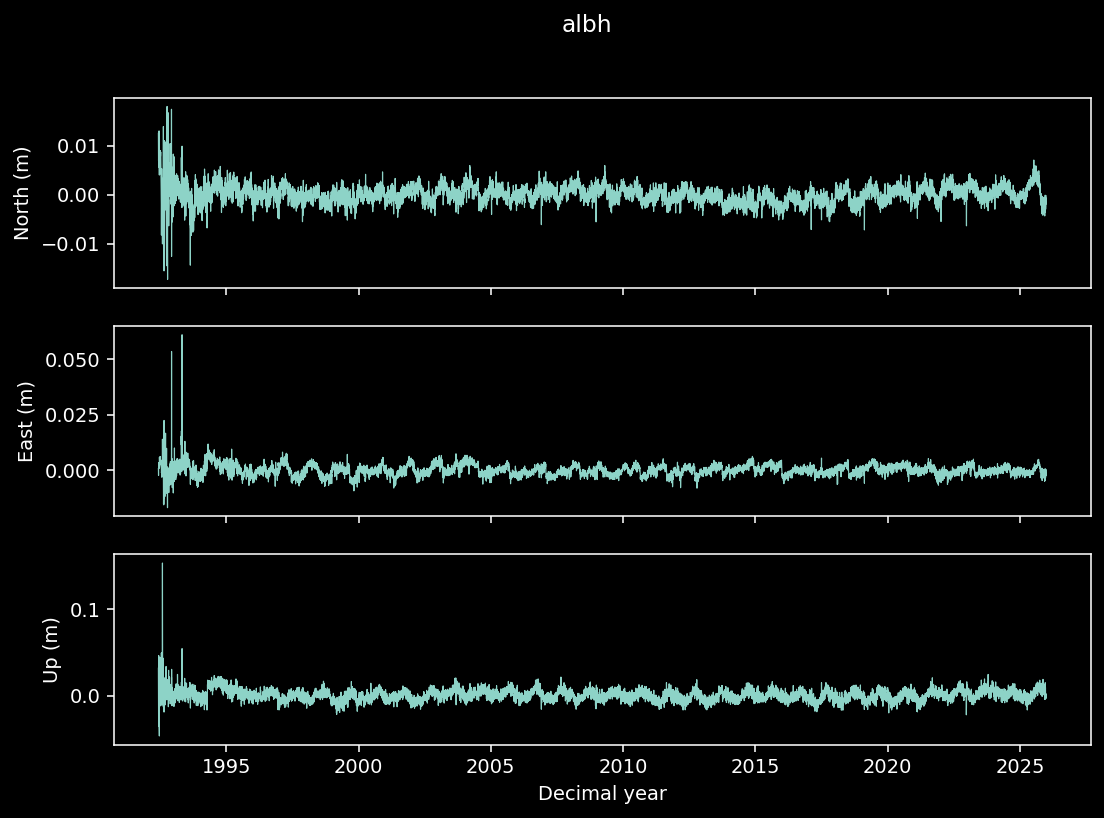

In [5]:
fig, ax = plt.subplots(3, 1, figsize=(9, 6), sharex=True)

ax[0].plot(ts.dec_year, ts.north_m, lw=0.6)
ax[0].set_ylabel("North (m)")

ax[1].plot(ts.dec_year, ts.east_m, lw=0.6)
ax[1].set_ylabel("East (m)")

ax[2].plot(ts.dec_year, ts.up_m, lw=0.6)
ax[2].set_ylabel("Up (m)")
ax[2].set_xlabel("Decimal year")

plt.suptitle(sample_station)
plt.show()

## 4) Apply filters: 2010→present and >5 years

In [6]:
station_list = pd.read_csv("./resources/catalog_subset_bbox.csv")
station_list

,name,lat,lon,elev_m
0,ABBY,49.072141,-122.197803,195.280394
1,ABOT,49.029436,-122.266570,-4.009165
2,AGNS,42.552765,-124.059114,51.368366
3,AL2H,48.389780,-123.487472,31.750396
4,ALB4,48.389740,-123.487687,30.890637
...,...,...,...,...
599,YCS2,46.941249,-122.590563,91.426696
600,YELM,46.948717,-122.605735,81.993392
601,YOCR,45.379102,-121.743553,1884.269527
602,YONC,43.634111,-123.298301,86.491947


In [7]:
START_YEAR = 2010.0
END_YEAR = 2025 + 1
MIN_YEARS = 5.0

def filter_window(ts: pd.DataFrame) -> pd.DataFrame:
    return ts[(ts.dec_year >= START_YEAR) & (ts.dec_year <= END_YEAR)].copy()

def has_min_span(ts: pd.DataFrame, min_years: float = MIN_YEARS) -> bool:
    if ts.empty:
        return False
    return float(ts.dec_year.max() - ts.dec_year.min()) >= float(min_years)

ts_by_station = {}   # <-- canonical output of Section 5
fail = []            # (station, filename, error)
missing_on_disk = [] # stations listed in CSV but file not found

for st in station_list.name.astype(str).str.strip().str.lower().tolist():
    p = DATA_DIR / f"{st}CleanDetrend.neu"  # adjust if .enu etc
    if not p.exists():
        missing_on_disk.append(st)
        continue

    try:
        ts = read_ats_file(p)
        ts = ats_to_clean(ts)
        ts = filter_window(ts)

        if has_min_span(ts):
            ts_by_station[st] = ts
        else:
            fail.append((st, p.name, f"Span < {MIN_YEARS}y after filtering"))
    except Exception as e:
        fail.append((st, p.name, str(e)))

valid_stations = sorted(ts_by_station.keys())
print(f"Valid stations loaded: {len(valid_stations)}")
print(f"Missing on disk: {len(missing_on_disk)}")
print(f"Failed (parse/filter/span): {len(fail)}")

Valid stations loaded: 340
Missing on disk: 244
Failed (parse/filter/span): 20


In [8]:
if missing_on_disk:
    print("\n--- Missing on disk (first 50) ---")
    for s in missing_on_disk[:50]:
        print(" ", s)

if fail:
    print("\n--- Failed (first 20) ---")
    for st, fname, err in fail[:20]:
        print(f" {st} ({fname}): {err}")



--- Missing on disk (first 50) ---
  abby
  abot
  al2h
  alb4
  bbay
  bcab
  bcbu
  bcch
  bcco
  bccq
  bccr
  bccy
  bcdn
  bcdt
  bces
  bcho
  bclc
  bclg
  bcli
  bcmr
  bcnn
  bcns
  bcph
  bcpm
  bcsc
  bcsf
  bcsk
  bcsm
  bcsq
  bcts
  bcvc
  bcvi
  bcvt
  bcws
  bfir
  blnp
  blvu
  bndm
  brnb
  brsp
  bsum
  c046
  ca1r
  cach
  cacr
  cacy
  caeu
  cafl
  cafm
  cami

--- Failed (first 20) ---
 agns (agnsCleanDetrend.neu): Span < 5.0y after filtering
 aldr (aldrCleanDetrend.neu): Span < 5.0y after filtering
 bcut (bcutCleanDetrend.neu): Span < 5.0y after filtering
 bton (btonCleanDetrend.neu): Span < 5.0y after filtering
 chco (chcoCleanDetrend.neu): Span < 5.0y after filtering
 dwh1 (dwh1CleanDetrend.neu): Span < 5.0y after filtering
 euch (euchCleanDetrend.neu): Span < 5.0y after filtering
 kels (kelsCleanDetrend.neu): Span < 5.0y after filtering
 mznt (mzntCleanDetrend.neu): Span < 5.0y after filtering
 newp (newpCleanDetrend.neu): Span < 5.0y after filtering
 nose (

In [9]:
ts_by_station

{'albh':         dec_year    yr  dayofyr   east_m  north_m     up_m  east_sigma_m  \
 6364   2010.0014  2010        1  0.00250  0.00216  0.00249       0.00212   
 6365   2010.0041  2010        2  0.00192  0.00218 -0.00061       0.00185   
 6366   2010.0068  2010        3  0.00204  0.00310 -0.00671       0.00172   
 6367   2010.0096  2010        4  0.00136  0.00302  0.00238       0.00172   
 6368   2010.0123  2010        5  0.00129  0.00324  0.00278       0.00199   
 ...          ...   ...      ...      ...      ...      ...           ...   
 12188  2025.9767  2025      357 -0.00069 -0.00142 -0.00339       0.00212   
 12189  2025.9795  2025      358  0.00033 -0.00200  0.00221       0.00238   
 12190  2025.9822  2025      359 -0.00095 -0.00068 -0.00160       0.00225   
 12191  2025.9849  2025      360 -0.00253 -0.00106  0.00050       0.00238   
 12192  2025.9877  2025      361 -0.00110 -0.00023 -0.00230       0.00199   
 
        north_sigma_m  up_sigma_m  
 6364         0.00153     0.00

## 5: xarray Dataset with dims (time, station) and station coords from catalog


In [10]:
def year_doy_to_datetime(year: pd.Series, doy: pd.Series) -> pd.DatetimeIndex:
    """
    Convert year + day-of-year to pandas DatetimeIndex.

    Parameters
    ----------
    year : pd.Series or array-like
        Integer calendar year (e.g. 2009)
    doy : pd.Series or array-like
        Day of year (1-based, 1..365/366)

    Returns
    -------
    pandas.DatetimeIndex
    """
    year = pd.Series(year, dtype="Int64")
    doy = pd.Series(doy, dtype="Int64")

    # Build Jan 1 of each year
    start = pd.to_datetime(year.astype(str) + "-01-01")

    # Day-of-year is 1-based → add (doy - 1) days
    return pd.DatetimeIndex(start + pd.to_timedelta(doy - 1, unit="D"))

In [13]:
list_ds = []
fail = []

for st, tmp_df in ts_by_station.items():
    try:
        df = tmp_df.copy()

        # build time index
        time = year_doy_to_datetime(df["yr"], df["dayofyr"])
        df = df.assign(time=time).set_index("time").sort_index()

        # drop columns you don't want as data vars (optional)
        # df = df.drop(columns=["yr", "dayofyr", "dec_yr"], errors="ignore")

        # convert to xarray and add station dimension
        ds_st = df.to_xarray().expand_dims(station=[st])

        list_ds.append(ds_st)

    except Exception as e:
        fail.append((st, str(e)))

ds = xr.concat(list_ds, dim="station", join="outer").sortby("time")

print(f"Stations concatenated: {ds.sizes['station']}")
print(f"Time steps (union):    {ds.sizes['time']}")
if fail:
    print(f"Failed stations:       {len(fail)} (first 10 below)")
    for st, err in fail[:10]:
        print(" ", st, "->", err)

Stations concatenated: 340
Time steps (union):    5840


In [14]:
ds

<xarray.Dataset> Size: 143MB
Dimensions:        (station: 340, time: 5840)
Coordinates:
  * station        (station) object 3kB 'albh' 'arli' 'asbu' ... 'yelm' 'yonc'
  * time           (time) datetime64[ns] 47kB 2010-01-01 ... 2025-12-27
Data variables:
    dec_year       (station, time) float64 16MB 2.01e+03 2.01e+03 ... nan nan
    yr             (station, time) float64 16MB 2.01e+03 2.01e+03 ... nan nan
    dayofyr        (station, time) float64 16MB 1.0 2.0 3.0 4.0 ... nan nan nan
    east_m         (station, time) float64 16MB 0.0025 0.00192 ... nan nan
    north_m        (station, time) float64 16MB 0.00216 0.00218 ... nan nan
    up_m           (station, time) float64 16MB 0.00249 -0.00061 ... nan nan
    east_sigma_m   (station, time) float64 16MB 0.00212 0.00185 ... nan nan
    north_sigma_m  (station, time) float64 16MB 0.00153 0.00141 ... nan nan
    up_sigma_m     (station, time) float64 16MB 0.0049 0.00438 ... nan nan

## 6) Station coords from catalog (CSV)

In [16]:
station_list["station"] = station_list["name"].astype(str).str.strip().str.lower()
station_list = station_list.set_index("station")

# 2) Align metadata rows to ds.station order
station_list_aligned = station_list.reindex(ds.station.to_numpy())

# 3) Assign as coordinates (xarray will keep station dimension)
ds = ds.assign_coords(
    lat=("station", station_list_aligned["lat"].to_numpy(dtype=np.float64)),
    lon=("station", station_list_aligned["lon"].to_numpy(dtype=np.float64)),
    elev_m=("station", station_list_aligned["elev_m"].to_numpy(dtype=np.float64)),
)
ds

<xarray.Dataset> Size: 143MB
Dimensions:        (station: 340, time: 5840)
Coordinates:
  * station        (station) object 3kB 'albh' 'arli' 'asbu' ... 'yelm' 'yonc'
  * time           (time) datetime64[ns] 47kB 2010-01-01 ... 2025-12-27
    lat            (station) float64 3kB 48.39 48.17 43.82 ... 41.73 46.95 43.63
    lon            (station) float64 3kB -123.5 -122.1 -121.4 ... -122.6 -123.3
    elev_m         (station) float64 3kB 31.77 23.29 1.509e+03 ... 81.99 86.49
Data variables:
    dec_year       (station, time) float64 16MB 2.01e+03 2.01e+03 ... nan nan
    yr             (station, time) float64 16MB 2.01e+03 2.01e+03 ... nan nan
    dayofyr        (station, time) float64 16MB 1.0 2.0 3.0 4.0 ... nan nan nan
    east_m         (station, time) float64 16MB 0.0025 0.00192 ... nan nan
    north_m        (station, time) float64 16MB 0.00216 0.00218 ... nan nan
    up_m           (station, time) float64 16MB 0.00249 -0.00061 ... nan nan
    east_sigma_m   (station, time) float64 16MB 0.00212 0.00185 ... nan nan
    north_sigma_m  (station, time) float64 16MB 0.00153 0.00141 ... nan nan
    up_sigma_m     (station, time) float64 16MB 0.0049 0.00438 ... nan nan

## 7) final cleanup and Write NetCDF

In [17]:
ds = ds.drop_vars(["yr", "dayofyr"], errors="ignore")

In [18]:
OUT_DIR = Path("./outputs")
OUT_DIR.mkdir(exist_ok=True)
OUT_NC = OUT_DIR / "gnss_SOPAC_2010_2025.nc"

encoding = {v: {"zlib": True, "complevel": 4} for v in ds.data_vars}
ds.to_netcdf(OUT_NC, encoding=encoding)
print("Wrote:", OUT_NC)


Wrote: outputs\gnss_SOPAC_2010_2025.nc


## 8) Smoke test: reopen and plot one station

<xarray.Dataset> Size: 111MB
Dimensions:        (station: 340, time: 5840)
Coordinates:
  * station        (station) <U4 5kB 'albh' 'arli' 'asbu' ... 'yelm' 'yonc'
  * time           (time) datetime64[ns] 47kB 2010-01-01 ... 2025-12-27
    lat            (station) float64 3kB ...
    lon            (station) float64 3kB ...
    elev_m         (station) float64 3kB ...
Data variables:
    dec_year       (station, time) float64 16MB ...
    east_m         (station, time) float64 16MB ...
    north_m        (station, time) float64 16MB ...
    up_m           (station, time) float64 16MB ...
    east_sigma_m   (station, time) float64 16MB ...
    north_sigma_m  (station, time) float64 16MB ...
    up_sigma_m     (station, time) float64 16MB ...


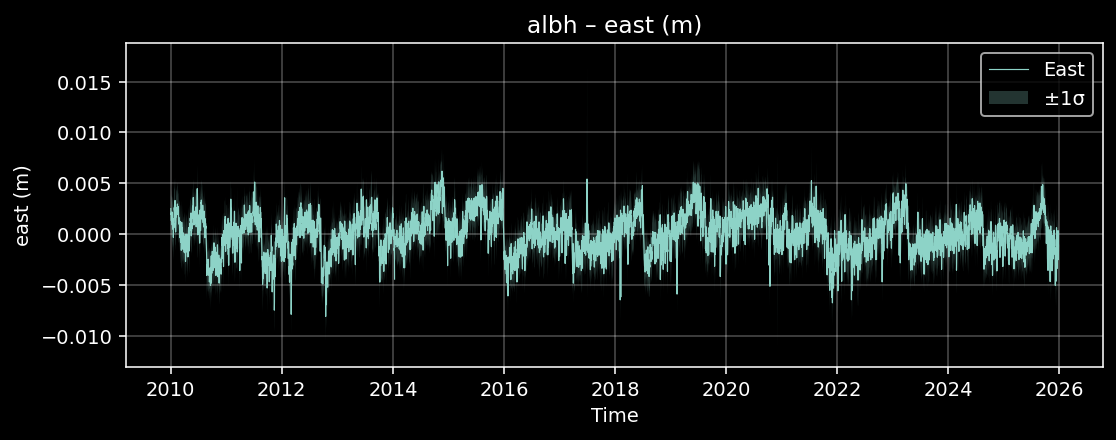

In [19]:
ds = xr.open_dataset(OUT_NC)
print(ds)

st = "albh"
sel = ds.sel(station=st)

plt.figure(figsize=(9, 3))

# central value
plt.plot(sel.time, sel.east_m, lw=0.6, label="East")

# ±1σ envelope
plt.fill_between(
    sel.time,
    sel.east_m - sel.east_sigma_m,
    sel.east_m + sel.east_sigma_m,
    alpha=0.25,
    linewidth=0,
    label="±1σ"
)

plt.title(f"{st} – east (m)")
plt.xlabel("Time")
plt.ylabel("east (m)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


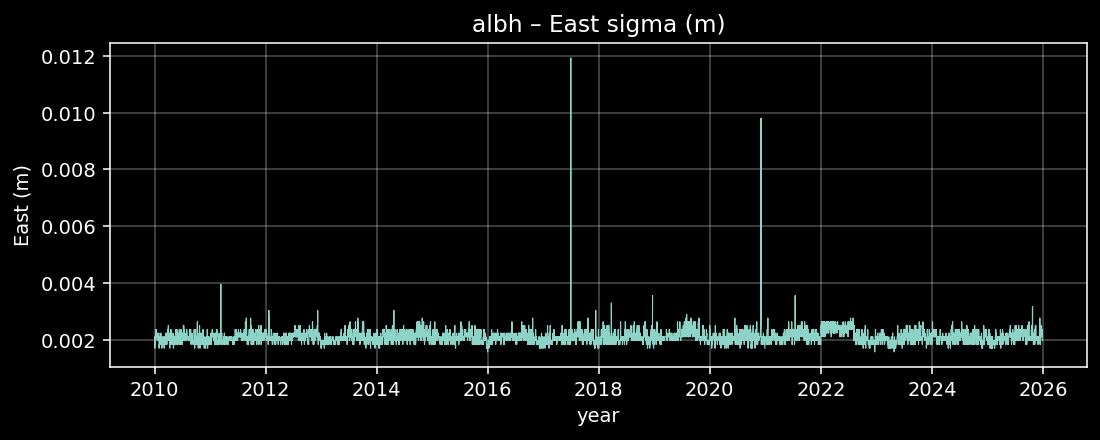

In [20]:
plt.figure(figsize=(9,3))
plt.plot(sel.time, sel.east_sigma_m, lw=0.6)
plt.title(f"{st} – East sigma (m)")
plt.xlabel("year")
plt.ylabel("East (m)")
plt.grid(True, alpha=0.3)
plt.show()

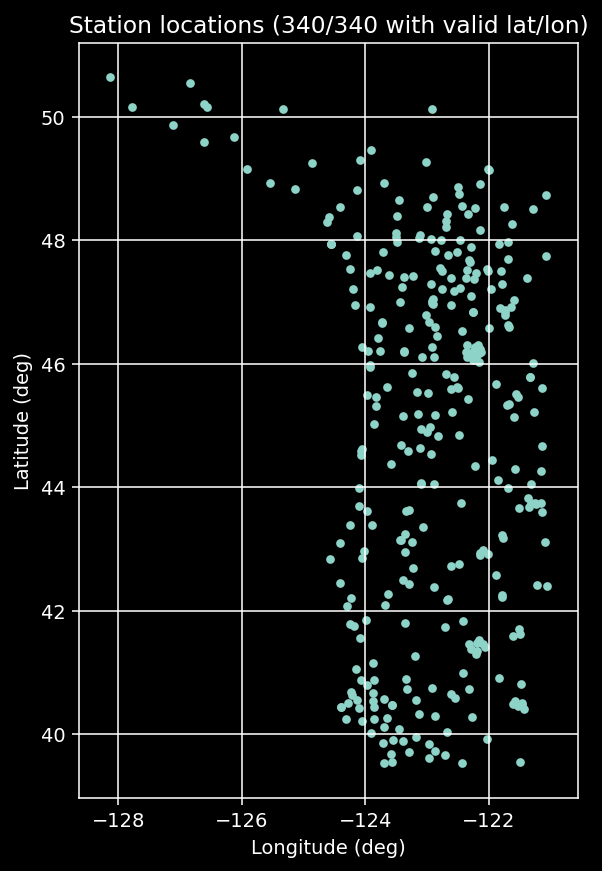

In [21]:
# --- grab station coords ---
lon = ds["lon"].values
lat = ds["lat"].values

mask = np.isfinite(lon) & np.isfinite(lat)
n_total = lon.size
n_ok = int(mask.sum())

# --- plot ---
plt.figure(figsize=(9, 7))
plt.scatter(lon[mask], lat[mask], s=12)  # (no explicit color per your style rule)
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title(f"Station locations ({n_ok}/{n_total} with valid lat/lon)")
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="box")

# nice bounds with padding
if n_ok > 0:
    xmin, xmax = np.nanmin(lon[mask]), np.nanmax(lon[mask])
    ymin, ymax = np.nanmin(lat[mask]), np.nanmax(lat[mask])
    pad_x = max(0.5, 0.05 * (xmax - xmin))
    pad_y = max(0.5, 0.05 * (ymax - ymin))
    plt.xlim(xmin - pad_x, xmax + pad_x)
    plt.ylim(ymin - pad_y, ymax + pad_y)

plt.show()